IMPORT VÀ CẤU HÌNH

In [116]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from tqdm import tqdm
import warnings
import gc
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight


In [117]:
# Dọn dẹp memory
torch.cuda.empty_cache()
gc.collect()
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Cấu hình
BONE_DATA_DIR = "/kaggle/input/notebooks/tonirighthere/notebook2/bone_data"
OUTPUT_DIR = "/kaggle/working/bilstm_model"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/checkpoints", exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU Memory at start: {torch.cuda.memory_allocated()/1024**2:.2f} MB")

print("GIAI ĐOẠN 4: BiLSTM + ATTENTION - DYNAMIC RECOGNITION")

Using device: cpu
GPU Memory at start: 0.00 MB
GIAI ĐOẠN 4: BiLSTM + ATTENTION - DYNAMIC RECOGNITION


1. LOAD METADATA

2. LOAD KEYPOINTS DATA

In [118]:
print("\n1. Loading metadata...")

# Tìm đúng đường dẫn
if not os.path.exists(f"{BONE_DATA_DIR}/bone_metadata.json"):
    BONE_DATA_DIR = "/kaggle/input/bone_data"
    
bone_metadata_path = f"{BONE_DATA_DIR}/bone_metadata.json"
if not os.path.exists(bone_metadata_path):
    print("ERROR: Không tìm thấy bone_metadata.json!")
    raise FileNotFoundError("Missing bone_metadata.json")

with open(bone_metadata_path, 'r') as f:
    metadata = json.load(f)

NUM_KEYPOINTS = keypoints_array.shape[1]   # 21 keypoints
FEATURES_PER_KEYPOINT = metadata.get('features_per_keypoint', 3)  # x, y, z
INPUT_FEATURE_SIZE = NUM_KEYPOINTS * FEATURES_PER_KEYPOINT  # 63 features
NUM_CLASSES = metadata['num_classes']
class_mapping = metadata['class_mapping']  # {'A': 0, 'B': 1, ...}
idx_to_class = metadata.get('idx_to_class', {str(v): k for k, v in class_mapping.items()})

print(f"Number of keypoints: {NUM_KEYPOINTS}")
print(f"Features per keypoint: {FEATURES_PER_KEYPOINT}")
print(f"Input feature size: {INPUT_FEATURE_SIZE}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class mapping sample: {dict(list(class_mapping.items())[:5])}")


1. Loading metadata...
Number of keypoints: 21
Features per keypoint: 3
Input feature size: 63
Number of classes: 29
Class mapping sample: {'0': 'A', '1': 'B', '2': 'C', '3': 'D', '4': 'E'}


In [119]:
print("\n2. Loading keypoints data...")

keypoints_path = f"{BONE_DATA_DIR}/keypoints_array.npy"
labels_path = f"{BONE_DATA_DIR}/labels_array.npy"

if not os.path.exists(keypoints_path):
    keypoints_path = "/kaggle/input/bone_data/keypoints_array.npy"
    labels_path = "/kaggle/input/bone_data/labels_array.npy"

keypoints_array = np.load(keypoints_path)
labels_array = np.load(labels_path)

print(f"Keypoints array shape: {keypoints_array.shape}")
print(f"Labels array shape: {labels_array.shape}")
print(f"Unique labels: {np.unique(labels_array)}")


2. Loading keypoints data...
Keypoints array shape: (10857, 21, 3)
Labels array shape: (10857,)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 28]


3. TẠO SEQUENCES CHO VIDEO SIMULATION

In [120]:
def extract_robust_features(keypoints):
    """
    Input: keypoints shape (N, 21, 3)
    Output: keypoints đã chuẩn hóa + đặc trưng khoảng cách + đặc trưng bắt chéo (N, 63 + 10 + 1 = 74)
    """
    # 1. B - Chuẩn hóa tọa độ tương đối (Wrist-relative)
    wrist = keypoints[:, 0:1, :] 
    keypoints_rel = keypoints - wrist 
    
    # Flatten về dạng (N, 63)
    features = keypoints_rel.reshape(keypoints.shape[0], -1)
    
    # 2. A - Tính toán khoảng cách giữa các đầu ngón tay (Finger-tip distances)
    tips = [4, 8, 12, 16, 20]
    extra_dists = []
    for i in range(len(tips)):
        for j in range(i + 1, len(tips)):
            dist = np.linalg.norm(keypoints[:, tips[i], :] - keypoints[:, tips[j], :], axis=1, keepdims=True)
            extra_dists.append(dist)
    
    # Gộp 10 đặc trưng khoảng cách -> (N, 10)
    extra_features = np.concatenate(extra_dists, axis=1)
    
    # 3. Đặc trưng bắt chéo (Phân biệt U và R) -> (N, 1)
    is_crossed = (keypoints[:, 12, 0] - keypoints[:, 8, 0]).reshape(-1, 1)
    
    # GỘP TẤT CẢ LẠI: features(63) + extra_features(10) + is_crossed(1) = 74 features
    final_features = np.concatenate([features, extra_features, is_crossed], axis=1)
    
    return final_features

# Áp dụng
print("Applying Robust Feature Engineering...")
keypoints_processed = extract_robust_features(keypoints_array)
print(f"New feature shape: {keypoints_processed.shape}") # Kết quả sẽ là (10857, 74)


Applying Robust Feature Engineering...
New feature shape: (10857, 74)


In [121]:
print("\n3. Creating sequences (Fixed for Data Leakage)...")

def create_sequences_fixed(keypoints, labels, seq_length=30, stride=15, split_ratio=0.7):
    X_train, y_train = [], []
    X_temp, y_temp = [], [] # Chứa cả Val và Test
    
    unique_labels = np.unique(labels)
    for label in unique_labels:
        indices = np.where(labels == label)[0]
        class_kps = keypoints[indices]
        
        # 1. Chia mốc thời gian: 70% đầu để train, 30% sau để (Val + Test)
        split_point = int(len(class_kps) * split_ratio)
        train_kps = class_kps[:split_point]
        temp_kps = class_kps[split_point:]
        
        # 2. Tạo sequence cho tập Train
        for i in range(0, len(train_kps) - seq_length, stride):
            X_train.append(train_kps[i:i+seq_length])
            y_train.append(label)
            
        # 3. Tạo sequence cho tập Temp (Val + Test)
        for i in range(0, len(temp_kps) - seq_length, stride):
            X_temp.append(temp_kps[i:i+seq_length])
            y_temp.append(label)
            
    return np.array(X_train), np.array(y_train), np.array(X_temp), np.array(y_temp)

# Cấu hình tham số
SEQ_LENGTH = 30
STRIDE = 15

# Gọi hàm FIXED (Xóa bỏ lệnh gọi create_sequences cũ đi nhé)
X_train, y_train, X_temp, y_temp = create_sequences_fixed(
    keypoints_processed, labels_array, seq_length=SEQ_LENGTH, stride=STRIDE
)

print(f"Train sequences: {X_train.shape}")
print(f"Temp (Val+Test) sequences: {X_temp.shape}")



3. Creating sequences (Fixed for Data Leakage)...
Train sequences: (463, 30, 74)
Temp (Val+Test) sequences: (173, 30, 74)


4. SPLIT DATA

In [122]:
print("\n4. Splitting Temp into Validation and Test (50/50)...")

# Chia tập Temp (30%) thành Val (15%) và Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    stratify=y_temp,
    random_state=42
)

print(f"Final Split Result:")
print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

# Bước này rất quan trọng: Flatten dữ liệu nếu cần
X_train_flat = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
X_val_flat = X_val.reshape(X_val.shape[0], X_val.shape[1], -1)
X_test_flat = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)

print(f"Input shape for model: {X_train_flat.shape}") # Sẽ là (..., 30, 74)



4. Splitting Temp into Validation and Test (50/50)...
Final Split Result:
Train: (463, 30, 74)
Validation: (86, 30, 74)
Test: (87, 30, 74)
Input shape for model: (463, 30, 74)


5. DATASET CLASS

In [123]:
class KeypointsSequenceDataset(Dataset):
    def __init__(self, sequences, labels, is_train=False):
        self.sequences = torch.FloatTensor(sequences)
        self.labels = torch.LongTensor(labels)
        self.is_train = is_train
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences[idx].clone()
        if self.is_train:
            # 1. Thêm nhiễu Gaussian nhẹ (Jittering - giả lập tay bị rung)
            noise = torch.randn_like(seq) * 0.015
            seq = seq + noise
            
            # 2. Random Temporal Shift (Mô phỏng động tác vung tay nhanh/chậm)
            if torch.rand(1).item() > 0.5:
                shift = torch.randint(-3, 4, (1,)).item()
                if shift > 0:
                    seq = torch.cat([seq[shift:], seq[-1:].repeat(shift, 1)])
                elif shift < 0:
                    seq = torch.cat([seq[0:1].repeat(-shift, 1), seq[:shift]])
                    
        return seq, self.labels[idx]

# Khởi tạo lại dataset (chỉ bật is_train=True cho tập train)
train_dataset = KeypointsSequenceDataset(X_train_flat, y_train, is_train=True)
val_dataset = KeypointsSequenceDataset(X_val_flat, y_val, is_train=False)
test_dataset = KeypointsSequenceDataset(X_test_flat, y_test, is_train=False)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


print(f"Batch size: {batch_size}")

Batch size: 32


6. ATTENTION MECHANISMS

In [124]:
class AdditiveAttention(nn.Module):
    """Additive attention (Bahdanau attention)"""
    def __init__(self, hidden_size):
        super(AdditiveAttention, self).__init__()
        self.attention = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        # x: (batch, seq_len, hidden_size)
        attention_weights = torch.softmax(self.attention(x).squeeze(-1), dim=1)
        context = torch.sum(x * attention_weights.unsqueeze(-1), dim=1)
        return context, attention_weights

class MultiHeadAttention(nn.Module):
    """Multi-head attention (Transformer style)"""
    def __init__(self, hidden_size, num_heads=4):
        super(MultiHeadAttention, self).__init__()
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads
        
        assert hidden_size % num_heads == 0, "hidden_size must be divisible by num_heads"
        
        self.query = nn.Linear(hidden_size, hidden_size)
        self.key = nn.Linear(hidden_size, hidden_size)
        self.value = nn.Linear(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, hidden_size)
        self.dropout = nn.Dropout(0.1)
        
    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        
        # Linear projections
        Q = self.query(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.key(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.value(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        
        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        attention_weights = torch.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        
        # Apply attention to values
        context = torch.matmul(attention_weights, V)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, self.hidden_size)
        
        return self.out(context), attention_weights

7. BiLSTM + ATTENTION MODEL

In [125]:
print("\n5. Building BiLSTM + Attention model...")

class BiLSTM_Attention(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, num_classes=29, 
                 dropout=0.3, attention_type='multihead'): 
        super(BiLSTM_Attention, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # 1. Dùng LayerNorm thay vì BatchNorm cho dữ liệu chuỗi (RẤT QUAN TRỌNG)
        self.layer_norm_in = nn.LayerNorm(input_size)
        
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0
        )
        
        if attention_type == 'additive':
            self.attention = AdditiveAttention(hidden_size * 2)
        else:
            self.attention = MultiHeadAttention(hidden_size * 2, num_heads=4)
        
        # 2. Classifier chuẩn thứ tự: Linear -> LayerNorm -> ReLU -> Dropout
        self.fc1 = nn.Linear(hidden_size * 2, 128)
        self.layer_norm_out = nn.LayerNorm(128)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # Normalize ngay từ đầu vào
        x = self.layer_norm_in(x)
        
        lstm_out, (hidden, cell) = self.lstm(x)
        context, attention_weights = self.attention(lstm_out)
        
        # === CHÈN THÊM 2 DÒNG NÀY ĐỂ FIX LỖI ===
        if context.dim() == 3:
            context = context.mean(dim=1)  # Gom các frames lại bằng Global Average Pooling
        # =======================================
        
        # Đi qua các lớp FC chuẩn
        out = self.fc1(context)
        out = self.layer_norm_out(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out, attention_weights



5. Building BiLSTM + Attention model...


In [126]:
# Model hyperparameters
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.3
ATTENTION_TYPE = 'multihead'  # 'additive' hoặc 'multihead'
                              # Đổi sang cơ chế Attention giống của Transformer  

model = BiLSTM_Attention(
    input_size=X_train_flat.shape[-1],
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
    attention_type=ATTENTION_TYPE
).to(device)


# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Attention type: {ATTENTION_TYPE}")
print(f"Hidden size: {HIDDEN_SIZE}")
print(f"Number of LSTM layers: {NUM_LAYERS}")

# Kiểm tra GPU memory
print(f"GPU memory after model: {torch.cuda.memory_allocated()/1024**2:.2f} MB")

Total parameters: 904,369
Trainable parameters: 904,369
Attention type: multihead
Hidden size: 128
Number of LSTM layers: 2
GPU memory after model: 0.00 MB


8. LOSS, OPTIMIZER, SCHEDULER

In [127]:
print("\n6. Setting up training...")

# Class weights cho imbalance
unique_labels_train = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=unique_labels_train, y=y_train)
class_weights_dict = {label: weight for label, weight in zip(unique_labels_train, class_weights)}

# Tạo mảng weights đầy đủ
full_weights = np.ones(NUM_CLASSES, dtype=np.float32)
for label, weight in class_weights_dict.items():
    full_weights[label] = weight

# Class 27 (nothing) có thể không có trong train
if 27 not in unique_labels_train:
    full_weights[27] = 0.0

class_weights_tensor = torch.tensor(full_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)


6. Setting up training...


9. TRAINING FUNCTIONS

In [128]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for sequences, labels in tqdm(loader, desc="Training"):
        sequences, labels = sequences.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(sequences)
        loss = criterion(outputs, labels)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total


In [129]:
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_attention_weights = []
    
    with torch.no_grad():
        for sequences, labels in tqdm(loader, desc="Validation"):
            sequences, labels = sequences.to(device), labels.to(device)
            outputs, attn_weights = model(sequences)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_attention_weights.append(attn_weights.cpu())
    
    return running_loss / len(loader), 100. * correct / total, all_attention_weights

10. TRAINING LOOP

In [130]:
print("\n7. Starting training...")

num_epochs = 50
best_val_acc = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 40)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _ = validate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    scheduler.step(val_loss)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"{OUTPUT_DIR}/checkpoints/best_bilstm_model.pth")
        print(f"Saved best model (val_acc: {val_acc:.2f}%)")
    
    # Early stopping
    if val_acc >= 95.0:
        print(f"Early stopping at epoch {epoch+1}")
        break


7. Starting training...

Epoch 1/50
----------------------------------------


Validation: 100%|██████████| 3/3 [00:00<00:00, 13.26it/s]


Train Loss: 3.0408, Train Acc: 14.47%
Val Loss: 2.3650, Val Acc: 41.86%
Saved best model (val_acc: 41.86%)

Epoch 2/50
----------------------------------------


Validation: 100%|██████████| 3/3 [00:00<00:00, 14.13it/s]


Train Loss: 1.9969, Train Acc: 60.91%
Val Loss: 1.5412, Val Acc: 88.37%
Saved best model (val_acc: 88.37%)

Epoch 3/50
----------------------------------------


Validation: 100%|██████████| 3/3 [00:00<00:00, 11.35it/s]

Train Loss: 1.2995, Train Acc: 83.80%
Val Loss: 0.9128, Val Acc: 96.51%
Saved best model (val_acc: 96.51%)
Early stopping at epoch 3


11. PLOT TRAINING CURVES


8. Plotting training curves...


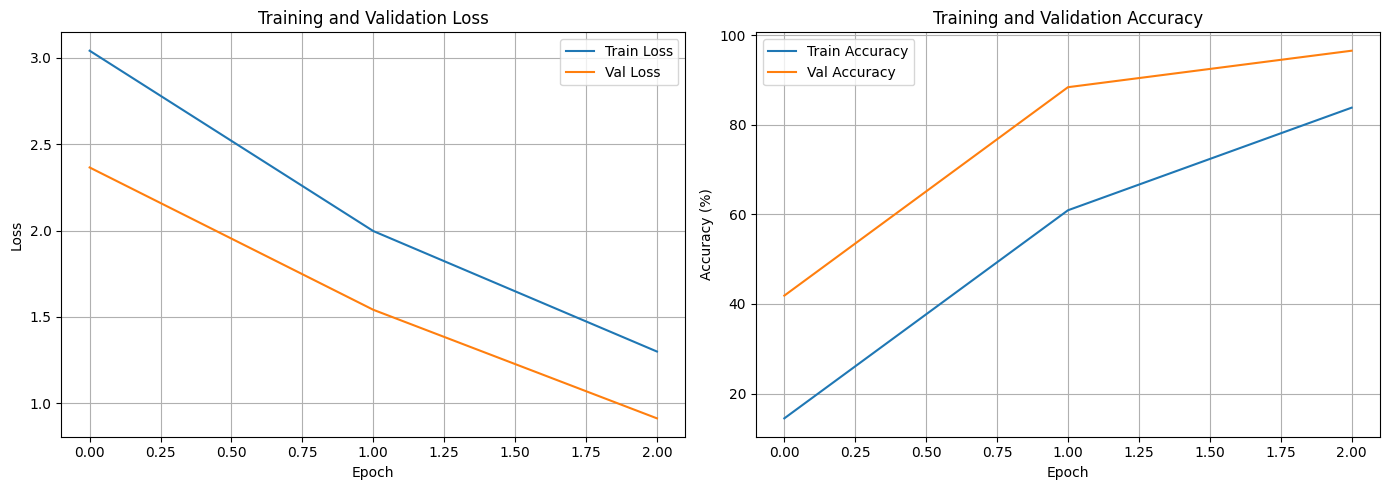

In [131]:
print("\n8. Plotting training curves...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_accs, label='Train Accuracy')
axes[1].plot(val_accs, label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png")
plt.show()

12. EVALUATE ON TEST SET


9. Evaluating on test set...


Testing: 100%|██████████| 3/3 [00:00<00:00, 12.88it/s]



Test Results:
Accuracy: 95.40%
Precision: 93.10%
Recall: 95.40%
F1-Score: 93.87%

Classification Report:
              precision    recall  f1-score   support

     Class_0       1.00      1.00      1.00         3
     Class_1       1.00      1.00      1.00         3
     Class_2       1.00      1.00      1.00         2
     Class_3       1.00      1.00      1.00         3
     Class_4       1.00      1.00      1.00         3
     Class_5       1.00      1.00      1.00         4
     Class_6       1.00      1.00      1.00         4
     Class_7       1.00      1.00      1.00         4
     Class_8       1.00      1.00      1.00         3
     Class_9       1.00      1.00      1.00         4
    Class_10       1.00      1.00      1.00         4
    Class_11       1.00      1.00      1.00         3
    Class_12       1.00      1.00      1.00         2
    Class_13       1.00      1.00      1.00         1
    Class_14       1.00      1.00      1.00         3
    Class_15       1.00      

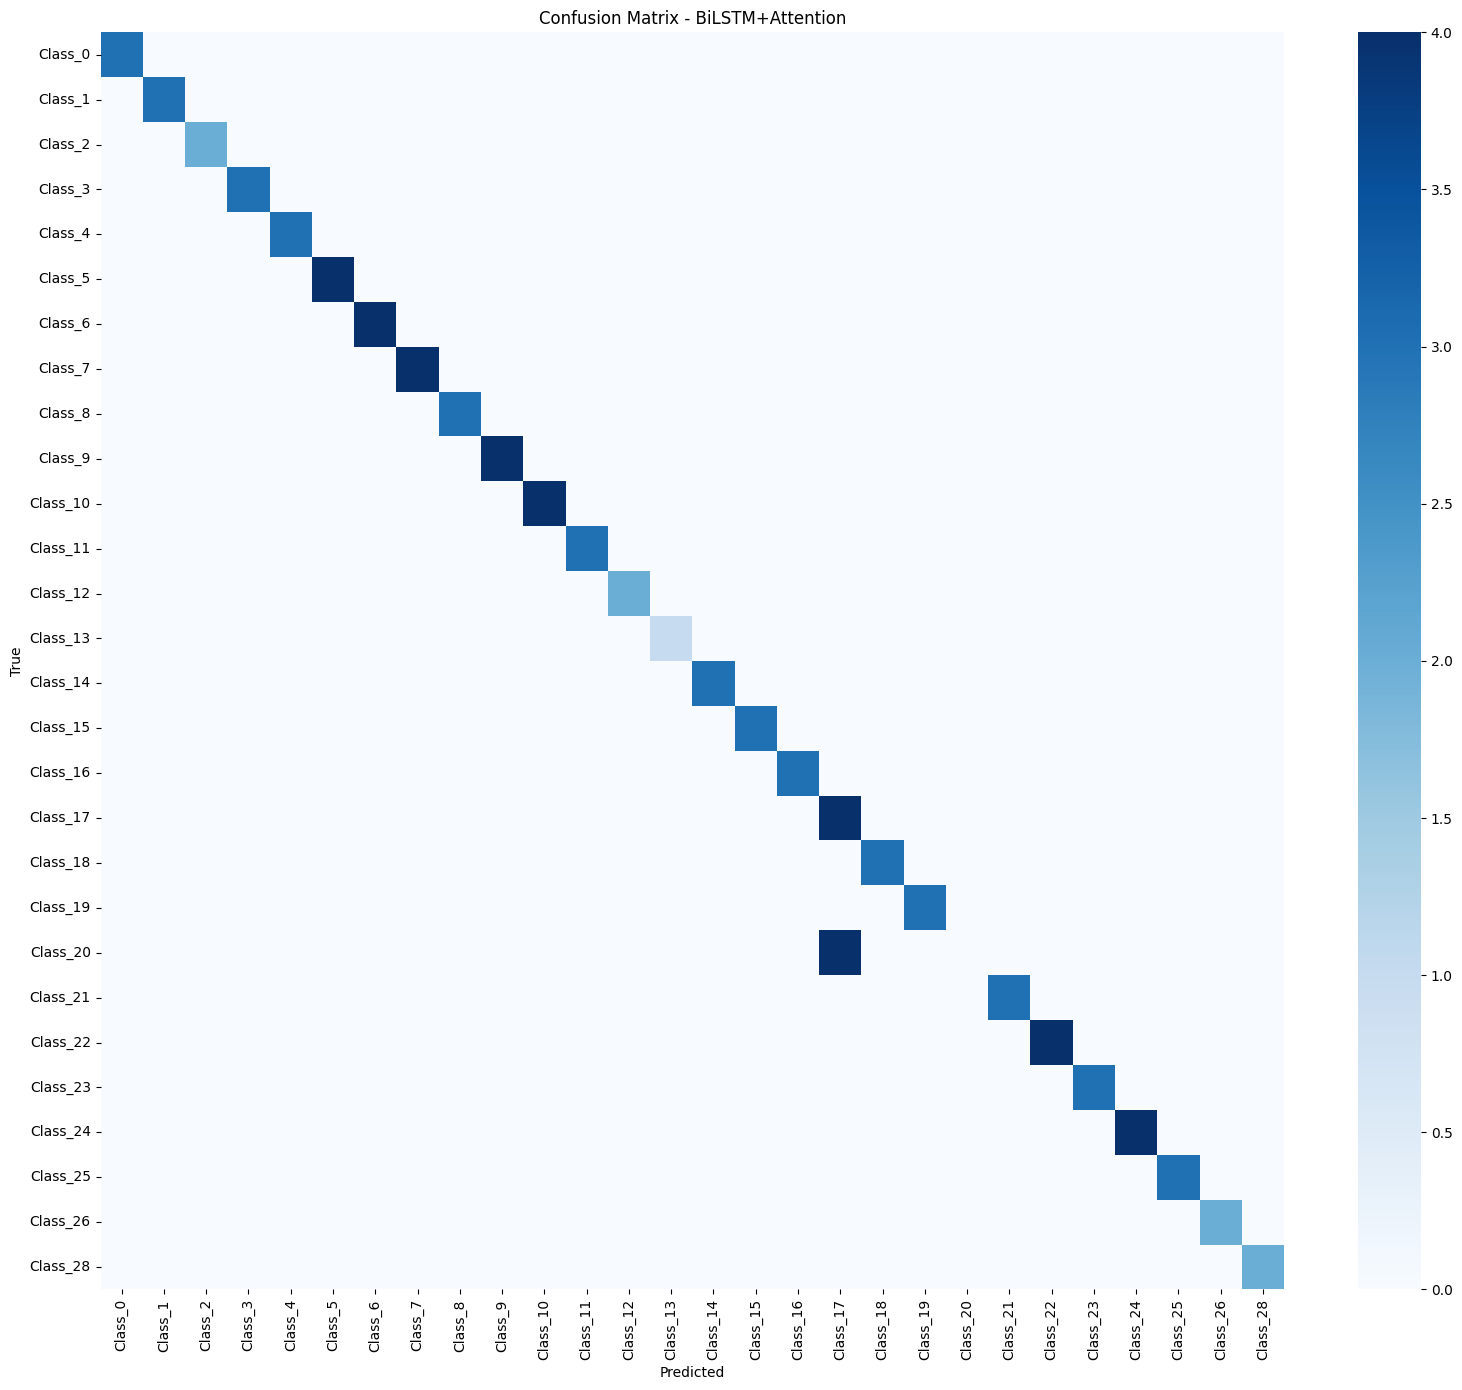

In [132]:
print("\n9. Evaluating on test set...")

# Load best model
model.load_state_dict(torch.load(f"{OUTPUT_DIR}/checkpoints/best_bilstm_model.pth"))
model.eval()

all_preds = []
all_labels = []
all_attentions = []

with torch.no_grad():
    for sequences, labels in tqdm(test_loader, desc="Testing"):
        sequences = sequences.to(device)
        outputs, attn_weights = model(sequences)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_attentions.append(attn_weights)

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"\nTest Results:")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")

# Classification report
unique_labels_test = np.unique(all_labels)
class_names = [idx_to_class.get(str(i), f"Class_{i}") for i in range(NUM_CLASSES) if i in unique_labels_test]

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix - BiLSTM+Attention')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png")
plt.show()

13. VISUALIZE ATTENTION WEIGHTS


10. Visualizing attention weights...


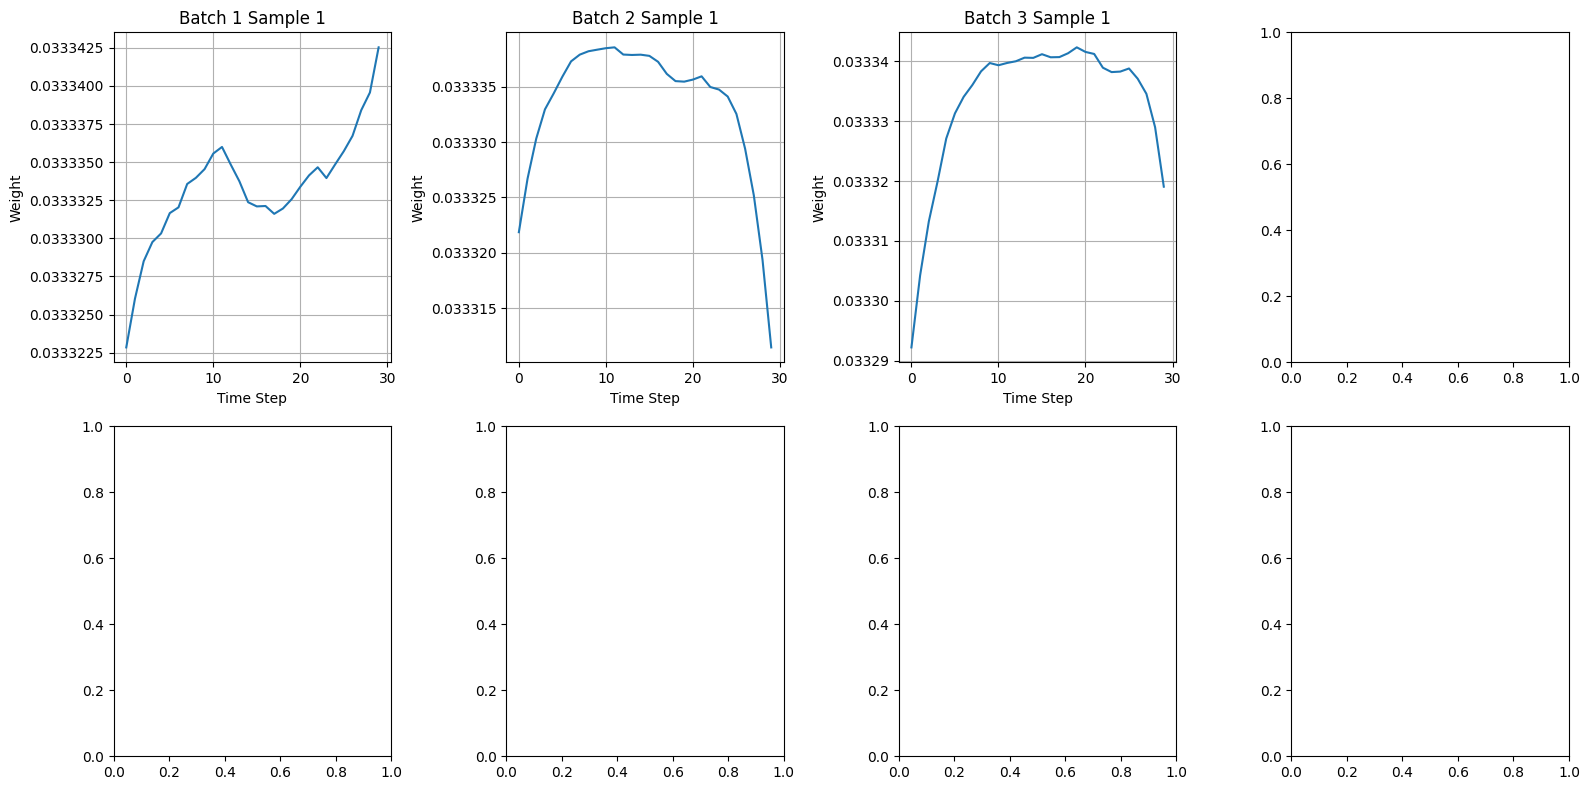

In [133]:
print("\n10. Visualizing attention weights...")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

# Duyệt qua các batch đầu tiên
for i in range(min(8, len(all_attentions))):
    attn_batch = all_attentions[i]
    # Lấy mẫu đầu tiên trong batch: attn sẽ có shape [4, 30, 30] hoặc [30]
    attn = all_attentions[i][0] 
    if attn.dim() == 3: # MultiHeadAttention [heads, seq, seq]
        attn = attn.mean(0).mean(0)
    elif attn.dim() == 2: # Trường hợp Self-Attention 2D: [seq_len, seq_len]
        attn = attn.mean(dim=0)
        
    attn_np = attn.cpu().numpy()
    
    axes[i].plot(attn_np)
    axes[i].set_title(f'Batch {i+1} Sample 1')
    axes[i].set_xlabel('Time Step')
    axes[i].set_ylabel('Weight')
    axes[i].grid(True)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/attention_weights.png")
plt.show()


14. SAVE MODEL

In [134]:
print("\n11. Saving model...")

model_info = {
    'model_type': 'BiLSTM_Attention',
    'attention_type': ATTENTION_TYPE,
    'input_size': INPUT_FEATURE_SIZE,
    'seq_length': SEQ_LENGTH,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'num_classes': NUM_CLASSES,
    'dropout': DROPOUT,
    'classes': [idx_to_class.get(str(i), f"Class_{i}") for i in range(NUM_CLASSES)],
    'test_accuracy': float(accuracy),
    'test_precision': float(precision),
    'test_recall': float(recall),
    'test_f1': float(f1),
    'best_val_acc': float(best_val_acc),
    'total_parameters': total_params
}

with open(f"{OUTPUT_DIR}/bilstm_model_info.json", 'w') as f:
    json.dump(model_info, f, indent=2)

# Save full model
torch.save({
    'model_state_dict': model.state_dict(),
    'class_mapping': class_mapping,
    'idx_to_class': idx_to_class,
    'input_size': INPUT_FEATURE_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'num_layers': NUM_LAYERS,
    'seq_length': SEQ_LENGTH,
    'model_info': model_info
}, f"{OUTPUT_DIR}/full_bilstm_model.pth")

# Export to ONNX
try:
    dummy_input = torch.randn(1, SEQ_LENGTH, INPUT_FEATURE_SIZE).to(device)
    torch.onnx.export(model, dummy_input, f"{OUTPUT_DIR}/bilstm_model.onnx",
                      input_names=['input'], output_names=['output'],
                      dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}})
    print("Exported to ONNX format")
except Exception as e:
    print(f"ONNX export failed (optional): {e}")


11. Saving model...
ONNX export failed (optional): No module named 'onnxscript'


In [135]:
print("\n" + "=" * 50)
print("HOÀN THÀNH GIAI ĐOẠN 4!")
print("=" * 50)
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print(f"Test accuracy: {accuracy*100:.2f}%")
print(f"Test F1-Score: {f1*100:.2f}%")
print(f"Total model parameters: {total_params:,}")
print(f"Model saved to: {OUTPUT_DIR}")

# Final memory cleanup
torch.cuda.empty_cache()
gc.collect()
print(f"Final GPU memory: {torch.cuda.memory_allocated()/1024**2:.2f} MB")

print("\nLưu ý: Save version và add /kaggle/working/bilstm_model làm dataset output")


HOÀN THÀNH GIAI ĐOẠN 4!
Best validation accuracy: 96.51%
Test accuracy: 95.40%
Test F1-Score: 93.87%
Total model parameters: 904,369
Model saved to: /kaggle/working/bilstm_model
Final GPU memory: 0.00 MB

Lưu ý: Save version và add /kaggle/working/bilstm_model làm dataset output


In [136]:
!zip -r /kaggle/working/model2.zip /kaggle/working

updating: kaggle/working/ (stored 0%)
updating: kaggle/working/bilstm_model/ (stored 0%)
updating: kaggle/working/bilstm_model/bilstm_model_info.json (deflated 63%)
updating: kaggle/working/bilstm_model/full_bilstm_model.pth (deflated 8%)
updating: kaggle/working/bilstm_model/training_curves.png (deflated 8%)
updating: kaggle/working/bilstm_model/checkpoints/ (stored 0%)
updating: kaggle/working/bilstm_model/checkpoints/best_bilstm_model.pth (deflated 8%)
updating: kaggle/working/bilstm_model/attention_weights.png (deflated 17%)
updating: kaggle/working/bilstm_model/confusion_matrix.png (deflated 34%)
updating: kaggle/working/.virtual_documents/ (stored 0%)
updating: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 67%)
